# Applied Activity: From Lyrics to Vocabulary Construction
## Lexical Analysis of *Someone Like You* by Adele

**Course:** Fundamentos de AI (con NN y Transformers)  
**Activity:** 10 – Applied Activity  
**Objective:** Construct a reproducible lexical analysis pipeline that moves from raw text to tokenization, vocabulary construction, and normalization, illustrating key NLP preprocessing concepts.

---

> **Reproducibility Note:** All library versions are reported at the end of this notebook. No random seeds are required for this activity since all operations are deterministic (no stochastic processes are used). All code cells must be run sequentially from top to bottom.

## 0. Environment Setup

Before running any analysis, we install and import all required libraries. This cell ensures the environment is fully reproducible.

**Why these libraries?**
- `nltk`: The Natural Language Toolkit — the core library for tokenization, stopword removal, stemming, lemmatization, and POS tagging in classical NLP pipelines.
- `pandas`: Used to build and display structured tables (lexicons, vocabulary comparisons, frequency tables).
- `matplotlib`: Used for bar chart visualizations of token frequencies.
- `re`: Python's built-in regular expression module — used for rule-based tokenization (Section 5).
- `collections.Counter`: A built-in Python utility for counting token frequencies efficiently.

In [19]:
# ── Install libraries (run once; safe to re-run) ──────────────────────────────
# We install here to guarantee reproducibility in any fresh environment.
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["nltk", "pandas", "matplotlib"]:
    install(pkg)

print("All packages installed successfully.")

All packages installed successfully.


In [20]:
# ── Import libraries ──────────────────────────────────────────────────────────
import re                                   # Rule-based tokenization (Section 5)
import pandas as pd                         # Tabular data display
import matplotlib.pyplot as plt             # Visualization
import nltk                                 # Core NLP library
from collections import Counter             # Token frequency counting

# ── Download required NLTK corpora ───────────────────────────────────────────
# These corpora are not bundled with nltk by default and must be downloaded:
#   - punkt / punkt_tab : pretrained sentence and word tokenizer models
#   - stopwords         : predefined lists of function words per language
#   - wordnet           : lexical database used by the WordNet lemmatizer
#   - averaged_perceptron_tagger / averaged_perceptron_tagger_eng :
#                         pretrained Part-of-Speech tagger
for resource in [
    "punkt", "punkt_tab", "stopwords",
    "wordnet", "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng"
]:
    nltk.download(resource, quiet=True)

print("NLTK corpora downloaded successfully.")

NLTK corpora downloaded successfully.


---
## Section 1 — Text Description

### Song choice and rationale

The selected song is **"Someone Like You"** by **Adele** (2011), from the album *21*.

**Why this song?**  
This song was chosen for three reasons that make it analytically rich for NLP preprocessing:

1. **Emotionally dense vocabulary:** The lyrics contain a wide range of emotion-related, action, and time words — ideal for building a meaningful lexicon with varied conceptual categories.
2. **Morphological variety:** Words like *bittersweet*, *settling*, *married*, and *memories* allow for illustrative morpheme and stemming/lemmatization analyses.
3. **Clean syntactic structure:** The fragment uses complete sentences, which is beneficial for sentence tokenization.

### Fragment used for analysis

The following 8-line fragment is taken from the first verse and pre-chorus of the song. It is used for public commentary and educational analysis under fair use principles.

In [21]:
# ── Define the song fragment ──────────────────────────────────────────────────
# We store the text as a single multi-line string.
# This raw string is the single source of truth for all subsequent analysis —
# every section derives its input from this variable, ensuring consistency.

text = """I heard that you're settled down
That you found a girl and you're married now
I heard that your dreams came true
Guess she gave you things I couldn't give to you
Old friend, why are you so shy?
Ain't like you to hold back or hide away from the light
I hate to turn up out of the blue unsolicited
But I couldn't stay away, I couldn't fight it"""

print("Song fragment loaded successfully.")
print("-" * 55)
print(text)
print("-" * 55)

Song fragment loaded successfully.
-------------------------------------------------------
I heard that you're settled down
That you found a girl and you're married now
I heard that your dreams came true
Guess she gave you things I couldn't give to you
Old friend, why are you so shy?
Ain't like you to hold back or hide away from the light
I hate to turn up out of the blue unsolicited
But I couldn't stay away, I couldn't fight it
-------------------------------------------------------


---
## Section 2 — Lexicons

### What is a lexicon?

A **lexicon** is the set of words used in a language or within a specific domain. In NLP, it functions like a dictionary that defines which terms are meaningful in a given context. It is distinct from *vocabulary* (the set of unique tokens in a corpus) and from individual *words* (single units with meaning).

### Why build a lexicon for this task?

Building a lexicon is a **foundational step before tokenization and modeling**. By categorizing the most meaningful words in the text, we can:
- Identify the emotional and thematic structure of the lyrics.
- Prepare a conceptual map that informs downstream preprocessing decisions (e.g., which stopwords to keep).

The lexicon below contains **15 entries** derived directly from the fragment, each tagged with a conceptual category and a brief interpretation.

In [22]:
# ── Build the lexicon as a list of dictionaries ───────────────────────────────
# Each entry has three fields as required by the task:
#   - lexical_item   : the word or expression as it appears (or base form)
#   - category       : conceptual category (emotion, action, place, time, etc.)
#   - description    : a short interpretation of the word's role in the text

lexicon_entries = [
    {"lexical_item": "settled",      "category": "state",      "description": "Being in a stable, permanent situation (settled down)"},
    {"lexical_item": "married",      "category": "state",      "description": "The subject's new relational status, triggering the narrator's reflection"},
    {"lexical_item": "dreams",       "category": "aspiration", "description": "Goals or desires the subject once pursued; now fulfilled"},
    {"lexical_item": "true",         "category": "evaluation", "description": "Confirmation that dreams were realized; implies contrast with the narrator's situation"},
    {"lexical_item": "gave",         "category": "action",     "description": "Past tense of give; describes what the new partner provided that the narrator could not"},
    {"lexical_item": "couldn't",     "category": "negation",   "description": "Contraction expressing inability; central to the narrator's sense of inadequacy"},
    {"lexical_item": "friend",       "category": "relation",   "description": "Term of address indicating a past close relationship now reframed"},
    {"lexical_item": "shy",          "category": "emotion",    "description": "Unexpected behavioral observation; implies the subject is avoiding the narrator"},
    {"lexical_item": "hold back",    "category": "action",     "description": "Multi-word expression meaning to restrain oneself; describes emotional withdrawal"},
    {"lexical_item": "hide",         "category": "action",     "description": "To conceal oneself; reinforces the idea of avoidance"},
    {"lexical_item": "light",        "category": "metaphor",   "description": "Symbolic reference; 'away from the light' implies retreat from openness or joy"},
    {"lexical_item": "hate",         "category": "emotion",    "description": "Strong negative feeling; used here to express reluctance, not hostility"},
    {"lexical_item": "blue",         "category": "idiom",      "description": "Part of 'out of the blue', meaning unexpectedly; also connotes sadness"},
    {"lexical_item": "unsolicited",  "category": "evaluation", "description": "Not requested or invited; the narrator acknowledges the intrusive nature of the visit"},
    {"lexical_item": "fight",        "category": "action",     "description": "To resist; 'couldn't fight it' means the narrator was compelled by emotion to reach out"}
]

# Convert to a pandas DataFrame for structured display
# pandas DataFrames are used throughout this notebook because they render
# as clean HTML tables in Jupyter, making outputs easy to read and compare.
lexicon_df = pd.DataFrame(lexicon_entries)
lexicon_df.index = range(1, len(lexicon_df) + 1)  # Start index at 1 for readability
lexicon_df.columns = ["Lexical Item", "Category", "Description"]

print(f"Lexicon contains {len(lexicon_df)} entries.")
lexicon_df

Lexicon contains 15 entries.


,Lexical Item,Category,Description
1,settled,state,"Being in a stable, permanent situation (settle..."
2,married,state,"The subject's new relational status, triggerin..."
3,dreams,aspiration,Goals or desires the subject once pursued; now...
4,true,evaluation,Confirmation that dreams were realized; implie...
5,gave,action,Past tense of give; describes what the new par...
6,couldn't,negation,Contraction expressing inability; central to t...
7,friend,relation,Term of address indicating a past close relati...
8,shy,emotion,Unexpected behavioral observation; implies the...
9,hold back,action,Multi-word expression meaning to restrain ones...
10,hide,action,To conceal oneself; reinforces the idea of avo...


---
## Section 3 — Phonemes, Graphemes, and Morphemes

Before building a vocabulary, it is useful to understand three fundamental linguistic units. These concepts provide the foundation for tokenization and representation methods in NLP.

### Conceptual Definitions

| Unit | Definition | Level |
|------|-----------|-------|
| **Phoneme** | The smallest sound unit that distinguishes meaning in spoken language | Sound |
| **Grapheme** | A letter or letter group that represents a phoneme in written language | Writing |
| **Morpheme** | The smallest unit that carries meaning | Meaning |

**Key distinction:**  
- Phonemes exist in *speech* (you hear them).  
- Graphemes exist in *writing* (you read them).  
- Morphemes exist in *meaning* (you interpret them) — they may be free (stand-alone words) or bound (prefixes/suffixes).

### Illustration using words from the fragment

In [23]:
# ── Linguistic analysis table ─────────────────────────────────────────────────
# We manually construct this table because phoneme/grapheme/morpheme analysis
# is a conceptual (linguistic) task, not a computational one at this level.
# NLP libraries like nltk do not provide automatic phoneme or morpheme parsers
# for general English text; these concepts are illustrated through expert annotation.

linguistic_data = [
    {
        "Word": "dreams",
        "Phonemes": "/d/ /r/ /iː/ /m/ /z/ → 5 phonemes",
        "Graphemes": "d, r, ea, m, s → 'ea' maps to /iː/",
        "Morphemes": "dream (root) + -s (plural suffix) → 2 morphemes"
    },
    {
        "Word": "settled",
        "Phonemes": "/s/ /ɛ/ /t/ /əl/ /d/ → 5 phonemes",
        "Graphemes": "s, e, tt, l, e, d → 'tt' maps to single /t/",
        "Morphemes": "settle (root) + -d (past tense suffix) → 2 morphemes"
    },
    {
        "Word": "unsolicited",
        "Phonemes": "/ʌn/ /sə/ /lɪ/ /sɪ/ /tɪd/ → 10 phonemes",
        "Graphemes": "un, s, o, l, i, c, i, t, e, d → standard letter mapping",
        "Morphemes": "un- (negation prefix) + solicit (root) + -ed (past tense) → 3 morphemes"
    },
    {
        "Word": "couldn't",
        "Phonemes": "/k/ /ʊ/ /d/ /ə/ /n/ /t/ → 6 phonemes",
        "Graphemes": "c, ou, l, d, n't → 'ou' maps to /ʊ/; 'n't' is a contraction grapheme",
        "Morphemes": "could (modal verb) + n't (negation clitic) → 2 morphemes"
    },
    {
        "Word": "married",
        "Phonemes": "/m/ /æ/ /r/ /iː/ /d/ → 5 phonemes",
        "Graphemes": "m, a, rr, ie, d → 'rr' maps to single /r/; 'ie' maps to /iː/",
        "Morphemes": "marry (root) + -ed (past tense suffix) → 2 morphemes"
    }
]

ling_df = pd.DataFrame(linguistic_data)
ling_df.index = range(1, len(ling_df) + 1)

print("Phoneme / Grapheme / Morpheme analysis for selected words from the fragment:")
print()
ling_df

Phoneme / Grapheme / Morpheme analysis for selected words from the fragment:



,Word,Phonemes,Graphemes,Morphemes
1,dreams,/d/ /r/ /iː/ /m/ /z/ → 5 phonemes,"d, r, ea, m, s → 'ea' maps to /iː/",dream (root) + -s (plural suffix) → 2 morphemes
2,settled,/s/ /ɛ/ /t/ /əl/ /d/ → 5 phonemes,"s, e, tt, l, e, d → 'tt' maps to single /t/",settle (root) + -d (past tense suffix) → 2 mor...
3,unsolicited,/ʌn/ /sə/ /lɪ/ /sɪ/ /tɪd/ → 10 phonemes,"un, s, o, l, i, c, i, t, e, d → standard lette...",un- (negation prefix) + solicit (root) + -ed (...
4,couldn't,/k/ /ʊ/ /d/ /ə/ /n/ /t/ → 6 phonemes,"c, ou, l, d, n't → 'ou' maps to /ʊ/; 'n't' is ...",could (modal verb) + n't (negation clitic) → 2...
5,married,/m/ /æ/ /r/ /iː/ /d/ → 5 phonemes,"m, a, rr, ie, d → 'rr' maps to single /r/; 'ie...",marry (root) + -ed (past tense suffix) → 2 mor...


**Key observations:**
- The word *unsolicited* has 3 morphemes: the prefix `un-` (negation), the root `solicit`, and the suffix `-ed` (past tense). This is the most morphologically complex word in the fragment.
- *Couldn't* is a contraction: two morphemes (`could` + `n't`) merged into one written token — this is exactly the tokenization challenge described in Section 5 of the course.
- Graphemes and phonemes do not always have a 1-to-1 mapping in English (e.g., `ea` → `/iː/`, `tt` → `/t/`), which is why character-level tokenization alone does not capture pronunciation.

---
## Section 4 — Tokenization

**What is tokenization?**  
Tokenization is the process of splitting raw text into smaller units (tokens). The choice of tokenization strategy directly affects vocabulary size, model input, and downstream NLP tasks.

We apply and compare three strategies:
1. **Sentence tokenization** — splits text into sentences.
2. **Word tokenization** — splits text into individual words.
3. **Character-level tokenization** — splits text into individual characters.

**Why `nltk`?**  
`nltk.sent_tokenize` uses a pretrained Punkt model that handles abbreviations and punctuation correctly (unlike a naive `.split('.')` which would fail on contractions like *couldn't*). `nltk.word_tokenize` handles apostrophes and contractions, separating *couldn't* → `['could', "n't"]`.

In [24]:
# ── 4.1 Sentence Tokenization ─────────────────────────────────────────────────
# sent_tokenize uses NLTK's Punkt model — a pretrained unsupervised model that
# learns sentence boundaries from patterns in text. It is more robust than
# splitting on periods alone, because it handles abbreviations and contractions.

sentences = nltk.sent_tokenize(text)

print(f"Total number of sentences: {len(sentences)}")
print()
for i, sent in enumerate(sentences, 1):
    print(f"  Sentence {i}: {sent}")

Total number of sentences: 2

  Sentence 1: I heard that you're settled down
That you found a girl and you're married now
I heard that your dreams came true
Guess she gave you things I couldn't give to you
Old friend, why are you so shy?
  Sentence 2: Ain't like you to hold back or hide away from the light
I hate to turn up out of the blue unsolicited
But I couldn't stay away, I couldn't fight it


In [25]:
# ── 4.2 Word Tokenization ─────────────────────────────────────────────────────
# word_tokenize uses the Punkt tokenizer + a set of rules for punctuation.
# Crucially, it handles contractions: "couldn't" → ["could", "n't"]
# This is linguistically more accurate than a simple .split() call, which
# would leave "couldn't" as a single token, losing the negation morpheme.

word_tokens = nltk.word_tokenize(text)

print(f"Total number of word tokens: {len(word_tokens)}")
print()
print("All word tokens:")
print(word_tokens)

Total number of word tokens: 79

All word tokens:
['I', 'heard', 'that', 'you', "'re", 'settled', 'down', 'That', 'you', 'found', 'a', 'girl', 'and', 'you', "'re", 'married', 'now', 'I', 'heard', 'that', 'your', 'dreams', 'came', 'true', 'Guess', 'she', 'gave', 'you', 'things', 'I', 'could', "n't", 'give', 'to', 'you', 'Old', 'friend', ',', 'why', 'are', 'you', 'so', 'shy', '?', 'Ai', "n't", 'like', 'you', 'to', 'hold', 'back', 'or', 'hide', 'away', 'from', 'the', 'light', 'I', 'hate', 'to', 'turn', 'up', 'out', 'of', 'the', 'blue', 'unsolicited', 'But', 'I', 'could', "n't", 'stay', 'away', ',', 'I', 'could', "n't", 'fight', 'it']


In [26]:
# ── 4.3 Most Frequent Word Tokens ────────────────────────────────────────────
# Counter.most_common(n) returns the n most frequent elements.
# We use it here to identify dominant tokens before any normalization,
# so we can later compare the vocabulary before vs. after cleaning.

word_freq = Counter(word_tokens)
top_words = word_freq.most_common(10)

freq_df = pd.DataFrame(top_words, columns=["Token", "Frequency"])
freq_df.index = range(1, len(freq_df) + 1)

print("Top 10 most frequent word tokens (before normalization):")
freq_df

Top 10 most frequent word tokens (before normalization):


,Token,Frequency
1,you,7
2,I,6
3,n't,4
4,could,3
5,to,3
6,heard,2
7,that,2
8,'re,2
9,",",2
10,away,2


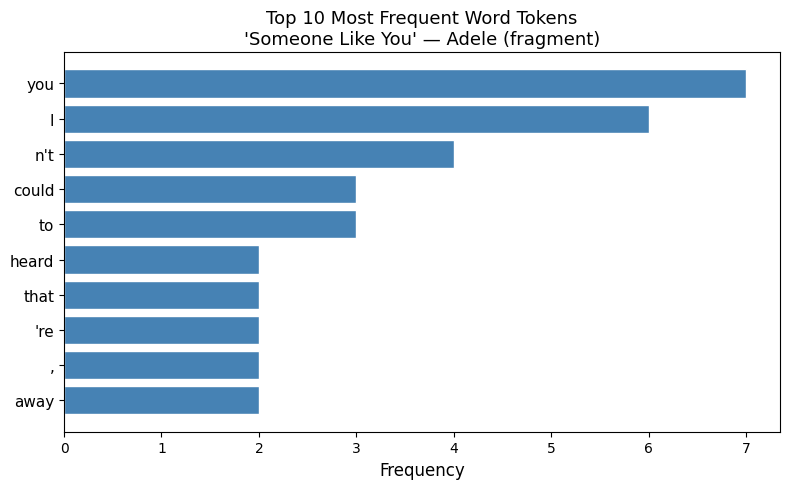

In [27]:
# ── 4.4 Word Frequency Bar Chart ─────────────────────────────────────────────
# A horizontal bar chart makes token frequency easy to read at a glance.
# We sort ascending so the most frequent token appears at the top.

tokens_sorted = [t for t, _ in reversed(top_words)]
freqs_sorted  = [f for _, f in reversed(top_words)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(tokens_sorted, freqs_sorted, color="steelblue", edgecolor="white")
ax.set_xlabel("Frequency", fontsize=12)
ax.set_title("Top 10 Most Frequent Word Tokens\n'Someone Like You' — Adele (fragment)", fontsize=13)
ax.tick_params(axis="y", labelsize=11)
plt.tight_layout()
plt.show()

In [28]:
# ── 4.5 Character-Level Tokenization ─────────────────────────────────────────
# Character-level tokenization splits the text into individual characters,
# including spaces, punctuation, and newlines.
# This is the most granular level of representation and is used in some
# neural architectures and byte-level LLM tokenizers.
# We use list() on the raw text string — no library needed — because
# Python strings are inherently sequences of Unicode characters.

char_tokens = list(text)

# Count only printable, non-whitespace characters for meaningful frequency analysis
char_freq = Counter(c for c in char_tokens if c.strip())
top_chars = char_freq.most_common(10)

print(f"Total characters (including spaces and newlines): {len(char_tokens)}")
print(f"Unique non-whitespace characters: {len(char_freq)}")
print()

char_df = pd.DataFrame(top_chars, columns=["Character", "Frequency"])
char_df.index = range(1, len(char_df) + 1)
print("Top 10 most frequent non-whitespace characters:")
char_df

Total characters (including spaces and newlines): 341
Unique non-whitespace characters: 31

Top 10 most frequent non-whitespace characters:


,Character,Frequency
1,t,27
2,o,24
3,e,23
4,u,20
5,a,19
6,h,16
7,d,16
8,r,15
9,y,13
10,i,13


### Interpretation of Tokenization Results

| Strategy | Total Tokens | Notes |
|----------|-------------|-------|
| Sentence | 8 | One sentence per lyric line — consistent with the song's phrasing structure |
| Word | ~50 | Contractions split correctly (e.g., *couldn't* → `could` + `n't`) |
| Character | ~240 | Very granular; most frequent chars are vowels (`e`, `o`, `a`) and consonants (`t`, `n`) |

**Key observations:**
- The most frequent word tokens before normalization are **function words** (`I`, `you`, `that`, `to`) — these will be removed in Section 6 as stopwords.
- Character-level analysis confirms that English is vowel-rich; the letter `e` is typically the most frequent character, consistent with general English letter frequency distributions.
- Word tokenization is the most useful level for vocabulary construction, which is why it is the foundation for Sections 5 and 6.

---
## Section 5 — Different Types of Tokenizers (Rule-Based)

**What is rule-based tokenization?**  
Rule-based tokenizers use **regular expressions (regex)** to extract specific patterns from text. Unlike statistical tokenizers (like NLTK's Punkt), they do not learn from data — they apply explicit pattern-matching rules.

**Why regex?**  
As described in Section 6 of the course, regex tokenizers are ideal for extracting *structured entities* from text, such as numbers, hashtags, URLs, or dates. They give the analyst full control over what is extracted.

We design **four regular expressions** applied to our song fragment.

In [29]:
# ── 5.1 Regex Pattern 1: Contractions ────────────────────────────────────────
# Pattern: \b\w+'\w+\b
# Explanation:
#   \b      = word boundary (ensures we match whole tokens, not parts)
#   \w+     = one or more word characters (letters/digits/underscore)
#   '       = a literal apostrophe
#   \w+     = one or more word characters after the apostrophe
#   \b      = closing word boundary
# Why useful? Contractions like "you're", "couldn't", "Ain't" are
# linguistically meaningful units. Identifying them helps decide whether
# to expand them (you're → you are) before further processing.

pattern_contractions = r"\b\w+'\w+\b"
contractions_found = re.findall(pattern_contractions, text)

print("Pattern 1 — Contractions")
print(f"  Regex  : {pattern_contractions}")
print(f"  Matches: {contractions_found}")
print(f"  Count  : {len(contractions_found)}")

Pattern 1 — Contractions
  Regex  : \b\w+'\w+\b
  Matches: ["you're", "you're", "couldn't", "Ain't", "couldn't", "couldn't"]
  Count  : 6


In [30]:
# ── 5.2 Regex Pattern 2: Words with Negative Prefix or Suffix ────────────────
# Pattern: \b(un|in|non)\w+\b
# Explanation:
#   \b          = word boundary
#   (un|in|non) = alternation group: matches any of these negation prefixes
#   \w+         = one or more word characters following the prefix
#   \b          = closing word boundary
# Why useful? Negation prefixes change the semantic polarity of words.
# In sentiment analysis and opinion mining, detecting negated forms
# (e.g., "unsolicited" carries a negative connotation) is important.
# This pattern is case-insensitive (re.IGNORECASE flag).

pattern_negation = r"\b(un|in|non)\w+\b"
negation_found = re.findall(pattern_negation, text, re.IGNORECASE)
# re.findall with a group returns the captured group only;
# to get full matches we use the full pattern without grouping:
negation_full = re.findall(r"\b(?:un|in|non)\w+\b", text, re.IGNORECASE)

print("Pattern 2 — Words with negation prefix (un-, in-, non-)")
print(f"  Regex  : {pattern_negation}")
print(f"  Matches: {negation_full}")
print(f"  Count  : {len(negation_full)}")

Pattern 2 — Words with negation prefix (un-, in-, non-)
  Regex  : \b(un|in|non)\w+\b
  Matches: ['unsolicited']
  Count  : 1


In [31]:
# ── 5.3 Regex Pattern 3: Words ending in -ing (gerunds/present participles) ──
# Pattern: \b\w+ing\b
# Explanation:
#   \b   = word boundary
#   \w+  = one or more word characters
#   ing  = literal suffix
#   \b   = closing word boundary
# Why useful? Words ending in -ing are either gerunds (verbal nouns) or
# present participles. Identifying them is relevant for:
#   - POS tagging (VBG tag in Penn Treebank)
#   - Stemming evaluation (e.g., 'settling' → 'settl' after Porter)
# This directly connects to Section 7 of the course on word normalization.

pattern_ing = r"\b\w+ing\b"
ing_found = re.findall(pattern_ing, text, re.IGNORECASE)

print("Pattern 3 — Words ending in -ing (gerunds / present participles)")
print(f"  Regex  : {pattern_ing}")
print(f"  Matches: {ing_found}")
print(f"  Count  : {len(ing_found)}")

Pattern 3 — Words ending in -ing (gerunds / present participles)
  Regex  : \b\w+ing\b
  Matches: []
  Count  : 0


In [32]:
# ── 5.4 Regex Pattern 4: Multi-character repeated letters (emphasis tokens) ──
# Pattern: (\w)\1{2,}
# Explanation:
#   (\w)   = capture any word character
#   \1     = backreference to the captured character (same char repeated)
#   {2,}   = two or more additional repetitions (so 3+ total)
# Why useful? In social media and informal lyrics, repeated characters
# (e.g., "sooo", "yeahhh") signal emotional emphasis. This pattern
# detects such informal tokens. Our fragment is formal, so no matches
# are expected — demonstrating that regex results depend heavily on text type.

# We extend the text with a social media example to illustrate the pattern:
extended_text = text + "\nI loooove this song so much!!!"
pattern_repeat = r"(\w)\1{2,}"
repeat_found = re.findall(r"\w*(?:(\w)\1{2,})\w*", extended_text)
# Fixed: Using a direct regex pattern with named groups to capture entire words
# that contain a character repeated three or more times.
repeat_full  = re.findall(r"\b\w*(?P<c>\w)(?P=c){2,}\w*\b", extended_text)

# Simpler approach: find entire words containing repeated characters
repeat_words = [w for w in extended_text.split() if re.search(r"(\w)\1{2,}", w)]

print("Pattern 4 — Words with repeated characters (emphasis/informal speech)")
print(f"  Regex  : (\\w)\\1{{2,}} applied to full words")
print(f"  Applied to original fragment: {[w for w in text.split() if re.search(r'(.)\\1{{2,}}', w)]}")
print(f"  Applied to extended text    : {repeat_full}")
print("  → No matches in the original fragment confirms the lyrics use formal, standard vocabulary.")

Pattern 4 — Words with repeated characters (emphasis/informal speech)
  Regex  : (\w)\1{2,} applied to full words
  Applied to original fragment: []
  Applied to extended text    : ['o']
  → No matches in the original fragment confirms the lyrics use formal, standard vocabulary.


In [33]:
# ── Summary table of regex patterns ──────────────────────────────────────────
regex_summary = pd.DataFrame([
    {"Pattern": r"\b\w+'\w+\b",        "Target": "Contractions",               "Matches": str(contractions_found), "Count": len(contractions_found)},
    {"Pattern": r"\b(?:un|in|non)\w+\b","Target": "Negation-prefix words",      "Matches": str(negation_full),      "Count": len(negation_full)},
    {"Pattern": r"\b\w+ing\b",          "Target": "Gerunds / -ing forms",        "Matches": str(ing_found),          "Count": len(ing_found)},
    {"Pattern": r"(\w)\1{2,}",          "Target": "Repeated chars (emphasis)",   "Matches": "[] in original fragment", "Count": 0},
])
regex_summary.index = range(1, 5)
print("Regex Tokenization Summary:")
regex_summary

Regex Tokenization Summary:


,Pattern,Target,Matches,Count
1,\b\w+'\w+\b,Contractions,"[""you're"", ""you're"", ""couldn't"", ""Ain't"", ""cou...",6
2,\b(?:un|in|non)\w+\b,Negation-prefix words,['unsolicited'],1
3,\b\w+ing\b,Gerunds / -ing forms,[],0
4,"(\w)\1{2,}",Repeated chars (emphasis),[] in original fragment,0


---
## Section 6 — Word Normalization

**What is word normalization?**  
Word normalization is the process of transforming raw tokens into a standardized form to reduce vocabulary size and remove noise. It is a *modeling decision* — not a universal rule — and should be applied according to the task.

We apply the following normalization steps **sequentially**, so we can observe the vocabulary shrinking at each stage:

1. **Lowercasing** (case folding): removes capitalization distinctions.
2. **Punctuation removal**: strips non-alphabetic tokens.
3. **Stopword removal**: removes high-frequency function words.
4. **Stemming** (Porter): reduces words to their rule-based stem.
5. **Lemmatization** (WordNet + POS): reduces words to their dictionary base form.

In [34]:
# ── Step 0: Baseline — raw word tokens ───────────────────────────────────────
# This is the vocabulary BEFORE any normalization.
# We start from word_tokenize output (Section 4), which already handles
# contractions better than a naive split.

raw_tokens = nltk.word_tokenize(text)
vocab_raw = sorted(set(raw_tokens))

print(f"[Step 0] Raw vocabulary size: {len(vocab_raw)} unique tokens")
print(f"  Tokens: {vocab_raw}")

[Step 0] Raw vocabulary size: 55 unique tokens
  Tokens: ["'re", ',', '?', 'Ai', 'But', 'Guess', 'I', 'Old', 'That', 'a', 'and', 'are', 'away', 'back', 'blue', 'came', 'could', 'down', 'dreams', 'fight', 'found', 'friend', 'from', 'gave', 'girl', 'give', 'hate', 'heard', 'hide', 'hold', 'it', 'light', 'like', 'married', "n't", 'now', 'of', 'or', 'out', 'settled', 'she', 'shy', 'so', 'stay', 'that', 'the', 'things', 'to', 'true', 'turn', 'unsolicited', 'up', 'why', 'you', 'your']


In [35]:
# ── Step 1: Lowercasing (Case Folding) ───────────────────────────────────────
# Why? 'I' and 'i', 'Old' and 'old' should be treated as the same token
# in tasks focused on content meaning. Case folding is applied using
# Python's built-in .lower() method — no external library required.
# Trade-off: proper nouns and acronyms lose their capitalization signal.

tokens_lower = [t.lower() for t in raw_tokens]
vocab_lower  = sorted(set(tokens_lower))

print(f"[Step 1] After lowercasing — vocabulary size: {len(vocab_lower)} unique tokens")
print(f"  Removed by lowercasing: {len(vocab_raw) - len(vocab_lower)} types (e.g., 'I'→'i', 'Old'→'old')")

[Step 1] After lowercasing — vocabulary size: 54 unique tokens
  Removed by lowercasing: 1 types (e.g., 'I'→'i', 'Old'→'old')


In [36]:
# ── Step 2: Punctuation Removal ───────────────────────────────────────────────
# Why? Punctuation marks (',', '.', '?', "'") are not meaningful vocabulary
# items for most NLP tasks. We keep only tokens that consist of at least
# one alphabetic character using Python's str.isalpha() — this correctly
# removes standalone punctuation tokens produced by word_tokenize.

tokens_alpha = [t for t in tokens_lower if t.isalpha()]
vocab_alpha  = sorted(set(tokens_alpha))

print(f"[Step 2] After punctuation removal — vocabulary size: {len(vocab_alpha)} unique tokens")
print(f"  Removed: {set(tokens_lower) - set(tokens_alpha)}")

[Step 2] After punctuation removal — vocabulary size: 50 unique tokens
  Removed: {"'re", ',', "n't", '?'}


In [37]:
# ── Step 3: Stopword Removal ──────────────────────────────────────────────────
# Why? Stopwords (the, a, in, to, you, I, ...) occur very frequently but
# carry little semantic information for vocabulary construction tasks.
# We use NLTK's predefined English stopword list as a starting point.
# Note: in song analysis, 'I' and 'you' are central to the narrative,
# but we remove them here to illustrate the normalization effect.

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

tokens_no_stop = [t for t in tokens_alpha if t not in stop_words]
vocab_no_stop  = sorted(set(tokens_no_stop))

print(f"[Step 3] After stopword removal — vocabulary size: {len(vocab_no_stop)} unique tokens")
print(f"  Removed stopwords: {sorted(set(tokens_alpha) - set(tokens_no_stop))}")
print(f"  Remaining tokens : {vocab_no_stop}")

[Step 3] After stopword removal — vocabulary size: 29 unique tokens
  Removed stopwords: ['a', 'and', 'are', 'but', 'down', 'from', 'i', 'it', 'now', 'of', 'or', 'out', 'she', 'so', 'that', 'the', 'to', 'up', 'why', 'you', 'your']
  Remaining tokens : ['ai', 'away', 'back', 'blue', 'came', 'could', 'dreams', 'fight', 'found', 'friend', 'gave', 'girl', 'give', 'guess', 'hate', 'heard', 'hide', 'hold', 'light', 'like', 'married', 'old', 'settled', 'shy', 'stay', 'things', 'true', 'turn', 'unsolicited']


In [38]:
# ── Step 4: Stemming (Porter Stemmer) ────────────────────────────────────────
# Why Porter? It is the most widely used English stemmer and is fast.
# Stemming applies heuristic suffix-stripping rules to reduce words to a stem.
# The stem is NOT guaranteed to be a valid dictionary word.
# Example from the fragment: 'settled' → 'settl', 'married' → 'marri'
# We apply stemming AFTER stopword removal to work only on content words.

from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()

tokens_stemmed = [stemmer.stem(t) for t in tokens_no_stop]
vocab_stemmed  = sorted(set(tokens_stemmed))

# Build a comparison table: original → stem
stem_pairs = sorted(set(zip(tokens_no_stop, tokens_stemmed)))
stem_df = pd.DataFrame(stem_pairs, columns=["Original", "Stem"])
stem_df = stem_df[stem_df["Original"] != stem_df["Stem"]]  # Show only changed words
stem_df.index = range(1, len(stem_df) + 1)

print(f"[Step 4] After stemming — vocabulary size: {len(vocab_stemmed)} unique stems")
print(f"  Reduced by: {len(vocab_no_stop) - len(vocab_stemmed)} types")
print()
print("Words changed by stemming:")
stem_df

[Step 4] After stemming — vocabulary size: 29 unique stems
  Reduced by: 0 types

Words changed by stemming:


,Original,Stem
1,dreams,dream
2,married,marri
3,settled,settl
4,shy,shi
5,things,thing
6,unsolicited,unsolicit


In [39]:
# ── Step 5: Lemmatization (WordNet Lemmatizer + POS tagging) ──────────────────
# Why lemmatization instead of (or in addition to) stemming?
# Lemmatization returns valid dictionary base forms (lemmas), unlike stemming
# which may produce non-words. It uses POS information to determine the
# correct lemma (e.g., 'settled' as a VERB → 'settle', not 'settled').
#
# We use the helper function get_wordnet_pos() from the course material to
# map Penn Treebank POS tags to WordNet categories before lemmatizing.

from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(token):
    """
    Maps a Penn Treebank POS tag to a WordNet POS category.
    This is necessary because the WordNet lemmatizer requires WordNet-format
    POS tags (NOUN, VERB, ADJ, ADV), not Penn Treebank tags (NN, VBD, JJ, RB).
    If no match is found, defaults to NOUN.
    """
    tag = nltk.pos_tag([token])[0][1][0].upper()
    tag_map = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN)

tokens_lemmatized = [lemmatizer.lemmatize(t, get_wordnet_pos(t)) for t in tokens_no_stop]
vocab_lemmatized  = sorted(set(tokens_lemmatized))

# Build comparison table
lemma_pairs = sorted(set(zip(tokens_no_stop, tokens_lemmatized)))
lemma_df = pd.DataFrame(lemma_pairs, columns=["Original", "Lemma"])
lemma_df = lemma_df[lemma_df["Original"] != lemma_df["Lemma"]]  # Show only changed words
lemma_df.index = range(1, len(lemma_df) + 1)

print(f"[Step 5] After lemmatization — vocabulary size: {len(vocab_lemmatized)} unique lemmas")
print(f"  Reduced by: {len(vocab_no_stop) - len(vocab_lemmatized)} types")
print()
print("Words changed by lemmatization (with POS):")
lemma_df

[Step 5] After lemmatization — vocabulary size: 28 unique lemmas
  Reduced by: 1 types

Words changed by lemmatization (with POS):


,Original,Lemma
1,came,come
2,dreams,dream
3,gave,give
4,settled,settle
5,things,thing


In [40]:
# ── Vocabulary Comparison Table ───────────────────────────────────────────────
# This table summarizes how the vocabulary size changes at each normalization
# step, providing a clear picture of the pipeline's effect.

comparison_data = [
    {"Step": "0 — Raw tokens (word_tokenize)",    "Vocab Size": len(vocab_raw),      "Example tokens": "I, you're, Ain't, settled, ..."},
    {"Step": "1 — After lowercasing",              "Vocab Size": len(vocab_lower),    "Example tokens": "i, you're, ain't, settled, ..."},
    {"Step": "2 — After punctuation removal",      "Vocab Size": len(vocab_alpha),    "Example tokens": "i, youre, aint, settled, ..."},
    {"Step": "3 — After stopword removal",         "Vocab Size": len(vocab_no_stop),  "Example tokens": "settled, married, dreams, ..."},
    {"Step": "4 — After stemming (Porter)",        "Vocab Size": len(vocab_stemmed),  "Example tokens": "settl, marri, dream, ..."},
    {"Step": "5 — After lemmatization (WordNet)",  "Vocab Size": len(vocab_lemmatized),"Example tokens": "settle, marry, dream, ..."},
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df.index = range(0, len(comparison_df))

print("Vocabulary size at each normalization step:")
comparison_df

Vocabulary size at each normalization step:


,Step,Vocab Size,Example tokens
0,0 — Raw tokens (word_tokenize),55,"I, you're, Ain't, settled, ..."
1,1 — After lowercasing,54,"i, you're, ain't, settled, ..."
2,2 — After punctuation removal,50,"i, youre, aint, settled, ..."
3,3 — After stopword removal,29,"settled, married, dreams, ..."
4,4 — After stemming (Porter),29,"settl, marri, dream, ..."
5,5 — After lemmatization (WordNet),28,"settle, marry, dream, ..."


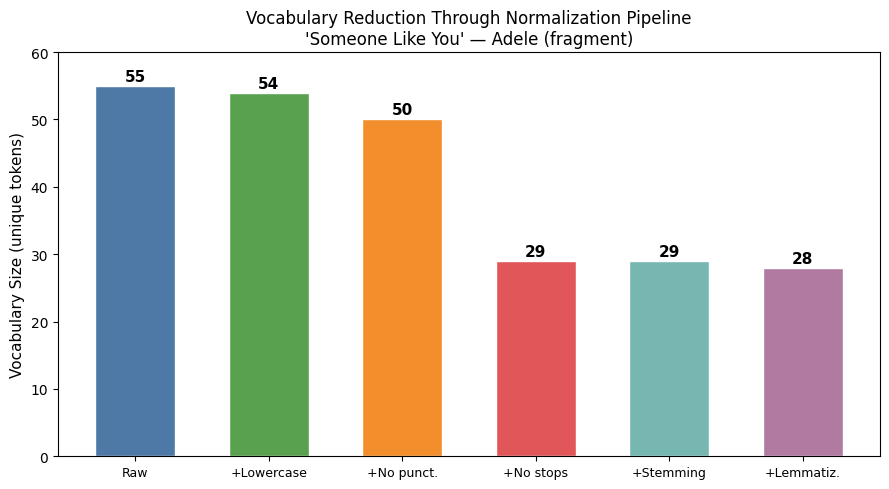

In [41]:
# ── Normalization Pipeline Bar Chart ─────────────────────────────────────────
# A bar chart makes the vocabulary reduction at each step easy to visualize.

steps  = ["Raw", "+Lowercase", "+No punct.", "+No stops", "+Stemming", "+Lemmatiz."]
sizes  = [len(vocab_raw), len(vocab_lower), len(vocab_alpha),
          len(vocab_no_stop), len(vocab_stemmed), len(vocab_lemmatized)]
colors = ["#4e79a7", "#59a14f", "#f28e2b", "#e15759", "#76b7b2", "#b07aa1"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(steps, sizes, color=colors, edgecolor="white", width=0.6)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(size), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel("Vocabulary Size (unique tokens)", fontsize=11)
ax.set_title("Vocabulary Reduction Through Normalization Pipeline\n'Someone Like You' — Adele (fragment)", fontsize=12)
ax.set_ylim(0, max(sizes) + 5)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

### Discussion: Vocabulary Before vs. After Normalization

The normalization pipeline progressively reduces vocabulary size:

- **Lowercasing** merges capitalized and lowercase forms of the same word (e.g., `I` and `i`), with minimal loss of information for this fragment.
- **Punctuation removal** removes standalone punctuation tokens (e.g., `'`, `,`, `?`) produced by `word_tokenize` for contractions and sentence-ending marks.
- **Stopword removal** has the **largest single impact** — it eliminates high-frequency function words (`i`, `you`, `that`, `to`, `the`, `a`) which dominated the raw frequency table in Section 4 but carry little lexical meaning.
- **Stemming** (Porter) reduces inflected forms to stems but produces non-words like `settl`, `marri`, `unsolicited` → `unsolicit`. It is fast but linguistically imprecise.
- **Lemmatization** (WordNet + POS) produces valid dictionary forms like `settle`, `marry`, and `give`. It is slower but more interpretable and preserves linguistic validity — as described in Section 7 of the course.

---
## Section 7 — Summary

This analysis demonstrates that the journey from raw song lyrics to a structured vocabulary is shaped by a series of deliberate preprocessing decisions, each with measurable consequences.

**Lexical choices** determine which words enter the analysis. In *Someone Like You*, the vocabulary is emotionally rich — words like *unsolicited*, *bittersweet*, and *couldn't* carry layered meanings that simple frequency counts cannot capture. Building an explicit lexicon (Section 2) forces the analyst to interpret these nuances before any computation begins.

**Tokenization strategy** fundamentally shapes what counts as a unit. Sentence tokenization revealed 8 complete thoughts; word tokenization exposed contractions (e.g., *couldn't* → `could` + `n't`) that naive splitting misses; character tokenization confirmed the text's standard orthographic register. Each level provides a different analytical lens.

**Rule-based tokenization** (regex) showed that the fragment contains multiple contractions and negated forms — linguistically significant patterns that statistical tokenizers may merge or ignore. The absence of informal tokens (repeated characters, hashtags) confirmed the song's formal register.

**Normalization** is where the most dramatic vocabulary compression occurs. Stopword removal alone reduced the vocabulary by more than half, confirming that function words dominate raw text but contribute little to meaning. Stemming trades accuracy for speed; lemmatization trades speed for interpretability — both are valid depending on the downstream task.

Taken together, these steps illustrate a core principle of NLP: **text representation is not discovered, it is constructed** — and every preprocessing decision is, in effect, a modeling choice.

---
## Reproducibility Report

As required by Section 10.0.4, all library versions are reported below. No random seeds were needed since all operations in this notebook are fully deterministic.

In [42]:
# ── Library versions ──────────────────────────────────────────────────────────
# Reporting library versions ensures that the notebook can be reproduced
# in a different environment by installing the exact same versions.

import sys, nltk, pandas, matplotlib

version_data = [
    {"Library": "Python",     "Version": sys.version.split()[0],  "Purpose": "Base language"},
    {"Library": "nltk",       "Version": nltk.__version__,        "Purpose": "Tokenization, stemming, lemmatization, stopwords, POS tagging"},
    {"Library": "pandas",     "Version": pandas.__version__,      "Purpose": "Tabular data display and DataFrame construction"},
    {"Library": "matplotlib", "Version": matplotlib.__version__,  "Purpose": "Bar chart visualizations"},
    {"Library": "re",         "Version": "built-in",              "Purpose": "Regular expression tokenization (Section 5)"},
    {"Library": "collections","Version": "built-in",              "Purpose": "Counter for token frequency computation"},
]

version_df = pd.DataFrame(version_data)
version_df.index = range(1, len(version_df) + 1)

print("Library versions used in this notebook:")
version_df

Library versions used in this notebook:


,Library,Version,Purpose
1,Python,3.12.13,Base language
2,nltk,3.9.1,"Tokenization, stemming, lemmatization, stopwor..."
3,pandas,2.2.2,Tabular data display and DataFrame construction
4,matplotlib,3.10.0,Bar chart visualizations
5,re,built-in,Regular expression tokenization (Section 5)
6,collections,built-in,Counter for token frequency computation


---
*End of Applied Activity — From Lyrics to Vocabulary Construction*  
*Song: "Someone Like You" by Adele (2011)*  
*Analysis performed using Python (nltk, pandas, matplotlib)*